## Practical session 6: Adaptive methods for stochastic opitmization

The goal of today's session is to implement two algorithms for stochastic optimization, namely, the so-called AdaGrad and Adam algorithms. The motivation behind these algorithms is to obtain convergence even without a deep knowledge of the problem at hand (for instance, to be able to choose good step sizes without knowing the Lipschitz constant of the gradient), and to account for possible heterogeneities across the dimensions of the problem (for instance, when one dimension of the problem yields very large, or small, gradients compared to the other).

### The Adagrad algorithm.

Consider the minimization of $f : \mathbb{R}^d \rightarrow \mathbb{R}$ on $\mathbb{R}^d$ given a noisy oracle $g$, that is, for any $x \in \mathbb{R}^d$, $\mathbb{E}[g(x)] = \nabla f (x)$. Stemming from second-order methods, Adagrad aims at constructing matrices $G_k$ such that each iteration is defined by
$$
x_{k+1} = x_k - \tau (G_k)^{-1/2} g(x_k).
$$
There is still a step-size $\tau$ involved in the above update, but the use of the matrix multiplication lessens its importance. Also, the fact that the $G_k$ are matrices allow for a distinct preconditionning for each dimension. For instance, a common choice is to have $G_k$ as diagonal, implying that for each component $i \in \{1,\dots,d\}$,
$$
(x_{k+1})_i = (x_k)_i - \tau \frac{(g_k)_i}{(G_k)_{i,i}^{1/2}}.
$$
This allows to have a distinct effect for every dimension. The choice of diagonal matrices is memory-efficient: Contrary to second-order methods such as Newton's method or BFGS, there is no need to store a $d \times d$ matrix, since we only need to store the $d$ diagonal elements.

Let us first introduce a simplified version of Adagrad, called Adagrad-norm. In this case, $G_k$ is just a scalar parameter. Initialize the algorithm with $x_0 \in \mathbb{R}^d$ and $G_0 = b$, where $b$ is a small positive scalar. Then, at iteration $k \in \mathbb{N}$, perform the following:
\begin{align*}
    g_k &= g(x_k)\\
    G_{k+1} &= G_k + \| g_k \|^2\\
    x_{k+1} &= x_k - \frac{\tau}{G_{k+1}^{1/2}} g_k.
\end{align*}

> Implement the Adagra-norm algorithm in the `algorithms.py` file.

Let us now give the full Adagrad algorithm. Initialize the algorithm with $x_0 \in \mathbb{R}^d$ and $G_0 = b I_d$, where $b$ is a small postive scalar. Then, at iteration $k \in \mathbb{N}$, perform the following:
\begin{align*}
    g_k &= g(x_k)\\
    G_{k+1} &= G_k + \textrm{diag}(g_k \odot g_k)\\
    x_{k+1} &= x_k - \tau ( G_{k+1} )^{-1/2} g_k.
\end{align*}
In the above, $\odot$ denotes the element-wise multiplication, and $\textrm{diag}$ maps a vector of $\mathbb{R}^d$ to the diagonal $d \times d$ matrix whose diagonal is this vector.

> Implement the Adagrad algorithm in the `algorithms.py` file.

### Back to  our logistic regression example

You are going to run the algorithms on the logistic regression task from Session 5. Recall that for this problem, the objective function $f$ is a sum of $m$ terms. Therefore, evaluating the full gradient can be costly in these settings and it is often more efficient to use a stochastic first-order oracle that for a given $x \in \mathbb{R}^d$ returns $\nabla f_i(x)$ where $i$ is sampled uniformly in $\{1,\dots,m\}$.

In [29]:
from algorithms import *  
from utils import *
import problem1 as pb
             
%load_ext autoreload
%autoreload 2
             
iterMax = 25000                     
x_init = np.zeros(pb.n)   

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


> Compare the Adagrad-norm and Adagrad algortihms with the SGD algorithm (consider only the final iterates) for constant and decreasing step-sizes. You can choose $\tau = f(x_0)$ for the Adagrad algorithms and $b = 10^{-6}$. Initialize all algorithms at $x_0 = 0_d$.

In [30]:
x_decr,x_decr_tab,x_avg_decr, x_avg_decr_tab = SGD(pb.f, pb.grad_f_subsampling, x_init, 1/pb.L, "decreasing", iterMax)
x_cons,x_cons_tab,x_avg_cons, x_avg_cons_tab = SGD(pb.f, pb.grad_f_subsampling, x_init, 1/pb.L, "constant", iterMax)
x_adagradNorm,x_adagradNorm_tab = adagrad_norm(pb.f, pb.grad_f_subsampling, x_init, pb.f(x_init), 0.000001, iterMax)
x_adagrad,x_adagrad_tab = adagrad_diag(pb.f, pb.grad_f_subsampling, x_init, pb.f(x_init), 0.000001, iterMax)

------------------------------------
 Stochastic gradient descent 
------------------------------------
START
FINISHED -- 24999 iterations -- 5.651908s -- final value: 0.469745


------------------------------------
 Stochastic gradient descent 
------------------------------------
START
FINISHED -- 24999 iterations -- 4.956826s -- final value: 0.362709


------------------------------------
 Adagrad-norm 
------------------------------------
START
FINISHED -- 24999 iterations -- 1.538552s -- final value: 0.363297


------------------------------------
 Adagrad 
------------------------------------
START
FINISHED -- 24999 iterations -- 1.962045s -- final value: 0.370591




In [31]:
f_decr = []
for i in range(x_decr_tab.shape[0]):
    f_decr.append( pb.f(x_decr_tab[i])) 


f_cons = []
for i in range(x_cons_tab.shape[0]):
    f_cons.append( pb.f(x_cons_tab[i])) 

f_adagrad_norm = []
for i in range(x_cons_tab.shape[0]):
    f_adagrad_norm.append( pb.f(x_adagradNorm_tab[i])) 
    
f_adagrad_diag = []
for i in range(x_cons_tab.shape[0]):
    f_adagrad_diag.append( pb.f(x_adagrad_tab[i])) 

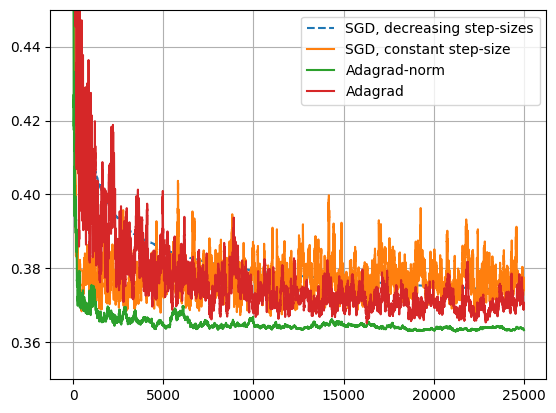

In [32]:


plt.figure()
plt.plot( f_decr, linewidth=1.5, linestyle="--",label='SGD, decreasing step-sizes')
plt.plot( f_cons, linewidth=1.5, linestyle="-",label='SGD, constant step-size')
plt.plot(f_adagrad_norm, linewidth=1.5, linestyle="-",label='Adagrad-norm')
plt.plot(f_adagrad_diag, linewidth=1.5, linestyle="-",label='Adagrad')

plt.ylim(0.35,0.45)

plt.grid(True)
plt.legend()
plt.show()

### The Adam algorithm

The Adam algorithm combines the ideas motivating Adagrad (adaptive pre-conditionning) and the idea of using momentum, as in accelerated gradient descent. The algorithm is intialized as $x_0 \in \mathbb{R}^d$, with additional variables $m_0 = 0_d$ and $v_0 = 0_d$. The algorithm has four scalar positive hyper-parameters $\tau, \beta_1, \beta_2, \delta$. The iteration $k \in \mathbb{N}$ is performed as follows:
\begin{align*}
    g_k &= G(x_k)\\
    m_{k+1} &= \beta_1 m_k + (1-\beta_1) g_k\\
    v_{k+1} &= \beta_2 v_k + (1-\beta_2) g_k \odot g_k\\
    \widehat{m_{k+1}} &= \frac{1}{1 - \beta_1^{k+1}} m_{k+1}\\
    \widehat{v_{k+1}} &= \frac{1}{1 - \beta_2^{k+1}} v_{k+1}\\
    x_{k+1} &= x_k - \tau (\delta I_d + \textrm{diag}(\widehat{v_{k+1}}))^{-1/2} \widehat{m_{k+1}}.
\end{align*}

> Implement the Adam algorithm, and compare it with the other algorithms considered in this session. Choose $\tau = 10^{-3}, \beta_1 = 0.9, \beta_2 = 0.999, \delta = 10^{-6}$.

In [33]:
x_adam, x_adam_tab = adam(pb.f, pb.grad_f_subsampling, x_init, 0.001, 0.9, 0.999, 0.000001, iterMax)

------------------------------------
 Adam 
------------------------------------
START
FINISHED -- 24999 iterations -- 2.722006s -- final value: 0.364380




In [34]:
f_adam = []
for i in range(x_cons_tab.shape[0]):
    f_adam.append( pb.f(x_adam_tab[i]))   

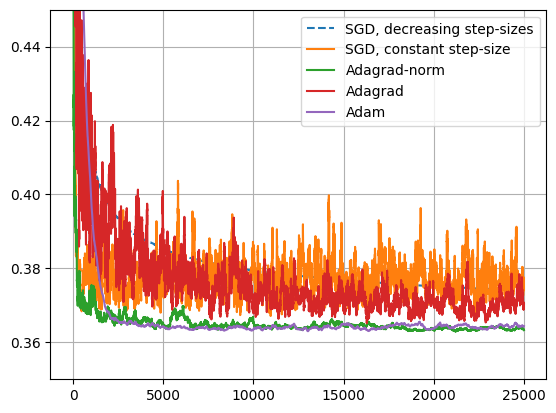

In [35]:
plt.figure()
plt.plot( f_decr, linewidth=1.5, linestyle="--",label='SGD, decreasing step-sizes')
plt.plot( f_cons, linewidth=1.5, linestyle="-",label='SGD, constant step-size')
plt.plot(f_adagrad_norm, linewidth=1.5, linestyle="-",label='Adagrad-norm')
plt.plot(f_adagrad_diag, linewidth=1.5, linestyle="-",label='Adagrad')
plt.plot(f_adam, linewidth=1.5, linestyle="-",label='Adam')

plt.ylim(0.35,0.45)

plt.grid(True)
plt.legend()
plt.show()